### 卷积神经网络与迁移学习教学版

本实验将完成两个目标：

1. 学会为自定义水果数据集创建 DataLoader。
2. 学会使用 ResNet18 进行迁移学习分类。

这份教学版特别修正了一个常见问题：训练集和测试集文件夹名称不一致时，类别编号会发生错位，导致测试准确率失真。

### 创建自己的 DataLoader

上节课的 MNIST 实验中，我们直接使用了 torchvision 内置数据集。现在换成自定义水果数据集后，除了读取图片本身，还要特别注意一个问题：

同一类别在 train 和 test 文件夹中的名字必须保持一致。否则即使模型预测正确，程序也可能因为类别编号映射不同而把结果判错。

这份代码会先对类别名称做统一规范化，例如：

1. 把 `Apple` 和 `apple` 统一成 `apple`。
2. 把 `Banana` 和 `banana` 统一成 `banana`。
3. 把拼写错误的 `stawberries` 统一成 `strawberries`。

In [2]:
import os
from collections import Counter
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np

# 检查设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

# 设置数据集路径：优先使用当前目录下已有的本地水果数据集
data_dir = './archive/MY_data/'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

# 设置超参数
batch_size = 32
num_epochs = 5
learning_rate = 0.001

# 统一类别名称，避免 train/test 文件夹命名不一致导致类别编号错位
canonical_classes = [
    'apple', 'avocado', 'banana', 'cherry', 'kiwi',
    'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon'
 ]
class_to_idx = {name: idx for idx, name in enumerate(canonical_classes)}
alias_map = {
    'apple': 'apple',
    'banana': 'banana',
    'stawberries': 'strawberries',
    'strawberries': 'strawberries',
}

def normalize_class_name(name):
    key = name.strip().lower() # 去除空格并转换为小写
    return alias_map.get(key, key) # 使用别名映射

# 训练集数据增强：帮助模型学习更稳健的特征
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), # 随机裁剪到 224x224
    transforms.RandomHorizontalFlip(),  # 随机水平翻转
    transforms.RandomRotation(15), # 随机旋转 ±15 度
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1), # 随机调整亮度、对比度、饱和度
    transforms.ToTensor(), # 转换为张量，并归一化到 [0, 1] 之间
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # 使用 ImageNet 的均值和标准差进行归一化
])

# 测试集只做尺寸调整和归一化
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 创建数据集类，负责加载图像和标签，并应用数据增强
class FruitDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []

        for folder_name in sorted(os.listdir(root_dir)):
            folder_path = os.path.join(root_dir, folder_name)
            if not os.path.isdir(folder_path):
                continue

            canonical_name = normalize_class_name(folder_name)
            if canonical_name not in class_to_idx:
                print(f'跳过未知类别文件夹: {folder_name}')
                continue

            label = class_to_idx[canonical_name]
            for file_name in sorted(os.listdir(folder_path)):
                if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                    self.samples.append((os.path.join(folder_path, file_name), label, canonical_name))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label, canonical_name = self.samples[index]
        image = Image.open(image_path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, label

# 创建训练集与测试集
train_dataset = FruitDataset(root_dir=train_dir, transform=train_transform)
test_dataset = FruitDataset(root_dir=test_dir, transform=test_transform)

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

# 获取类别信息
class_names = canonical_classes
num_classes = len(class_names)
print(f'类别数量: {num_classes}')
print(f'统一后的类别名称: {class_names}')
print(f'训练集样本数: {len(train_dataset)}')
print(f'测试集样本数: {len(test_dataset)}')

# 统计每个类别的样本数，帮助同学观察数据是否均衡
train_counter = Counter(label for _, label, _ in train_dataset.samples)
test_counter = Counter(label for _, label, _ in test_dataset.samples)
print('训练集各类别样本数:')
for class_name in class_names:
    label = class_to_idx[class_name]
    print(f'  {class_name}: {train_counter[label]}')

print('测试集各类别样本数:')
for class_name in class_names:
    label = class_to_idx[class_name]
    print(f'  {class_name}: {test_counter[label]}')

使用设备: cuda
类别数量: 10
统一后的类别名称: ['apple', 'avocado', 'banana', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon']
训练集样本数: 2301
测试集样本数: 1025
训练集各类别样本数:
  apple: 230
  avocado: 230
  banana: 230
  cherry: 230
  kiwi: 230
  mango: 231
  orange: 230
  pinenapple: 230
  strawberries: 230
  watermelon: 230
测试集各类别样本数:
  apple: 89
  avocado: 105
  banana: 106
  cherry: 105
  kiwi: 105
  mango: 105
  orange: 97
  pinenapple: 105
  strawberries: 103
  watermelon: 105


### 使用 ResNet18 进行迁移学习

这里使用 ImageNet 预训练的 ResNet18 作为特征提取器，只替换最后的全连接层。这样的好处是：

1. 训练速度更快。
2. 小数据集也能获得较好的初始效果。
3. 更适合课堂上演示“迁移学习”的核心思想。

In [4]:
# 最基础的加载 resnet18 的方式：加载预训练模型，替换最后一层
weights = models.ResNet18_Weights.DEFAULT # weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)
print(model) # 打印模型结构，帮助同学理解每一层的作用

# 冻结特征提取层，只训练最后的全连接层
for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes) # 替换最后一层
model = model.to(device) # 将模型移动到 GPU 上

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Epoch [1/5] Train Loss: 1.6553, Train Acc: 0.4972, Test Loss: 1.0034, Test Acc: 0.7493
Epoch [2/5] Train Loss: 0.9907, Train Acc: 0.7184, Test Loss: 0.7193, Test Acc: 0.8059
Epoch [3/5] Train Loss: 0.7898, Train Acc: 0.7792, Test Loss: 0.6070, Test Acc: 0.8263
Epoch [4/5] Train Loss: 0.7040, Train Acc: 0.8010, Test Loss: 0.5962, Test Acc: 0.8127
Epoch [5/5] Train Loss: 0.6445, Train Acc: 0.8162, Test Loss: 0.5430, Test Acc: 0.8244


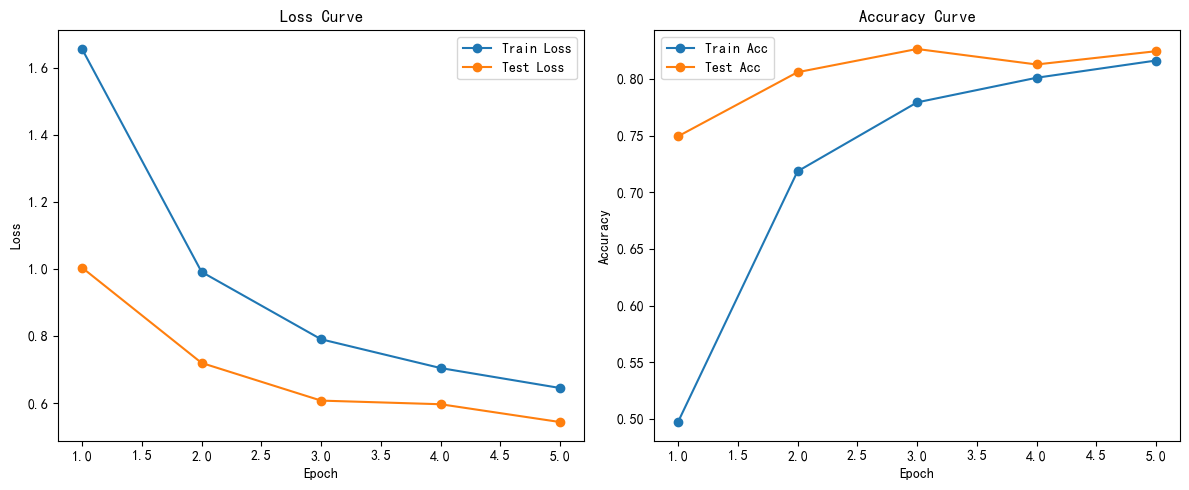

训练完成，最佳测试准确率: 0.8263414634146341
最佳模型已保存为 best_resnet18_simple.pth


In [21]:
# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=learning_rate)

# 训练 + 验证
best_acc = 0.0
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
}

for epoch in range(num_epochs):
    # 训练
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / len(train_dataset)
    train_acc = train_correct / train_total

    # 验证
    model.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss_sum += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

    test_loss = test_loss_sum / len(test_dataset)
    test_acc = test_correct / test_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    # 保存最佳模型
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': class_names,
        }, 'best_resnet18_simple.pth')

# 可视化训练与测试曲线
epoch_axis = range(1, num_epochs + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_axis, history['train_loss'], marker='o', label='Train Loss')
plt.plot(epoch_axis, history['test_loss'], marker='o', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_axis, history['train_acc'], marker='o', label='Train Acc')
plt.plot(epoch_axis, history['test_acc'], marker='o', label='Test Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.tight_layout()
plt.show()

print('训练完成，最佳测试准确率:', best_acc)
print('最佳模型已保存为 best_resnet18_simple.pth')

<summary>💡为什么测试集的精度高于训练集？</summary>
<details>
这是一个正常现象，而且在这份教程里更容易出现，因为训练集用了更强的数据增强，测试集只做了尺寸调整和归一化。合理，而且在你这份 ResNet 教程里很常见。

原因主要有两个：训练集用了更强的数据增强，比如随机裁剪、翻转、旋转和颜色扰动，所以训练时看到的数据更“难”；而测试集只做了 resize 和 normalize，没有这些扰动。再加上 ResNet18 训练时处于 train() 模式，BatchNorm 会按当前批次统计，训练精度本来就可能比测试更低一点。像你现在这种训练精度约 81.6%，测试精度约 82.4%，这种小幅倒挂是可以接受的，不算异常。

只有在以下情况才需要警惕：测试精度明显高很多、或者高得离谱，那就要检查是否有数据泄漏、训练/测试划分是否重复、或者评估流程是否有问题。更公平的比较方式，是把训练集也用 eval() 模式再跑一遍，或者去掉训练增强后再算一次训练集准确率。</details>


### ResNet18 可视化：特征图与随机样例回看

这部分可视化分成两步：

1. 先随机抽取一张测试图片，观察 ResNet18 在各层里“看到了什么”。
2. 再随机抽取 2 张预测正确样本和 2 张预测错误样本，比较模型在把握较强和容易混淆时的输出差异。

这样同学们可以同时从“中间特征”和“最终预测结果”两个角度理解迁移学习模型。

已加载最佳模型参数: best_resnet18_simple.pth
随机样本索引: 169
测试图片路径: ./archive/MY_data/test\avocado\img_691.jpeg
真实类别: avocado
预测类别: avocado
各层张量尺寸变化:
输入: (1, 3, 224, 224)
Stem: (1, 64, 56, 56)
Layer1: (1, 64, 56, 56)
Layer2: (1, 128, 28, 28)
Layer3: (1, 256, 14, 14)
Layer4: (1, 512, 7, 7)


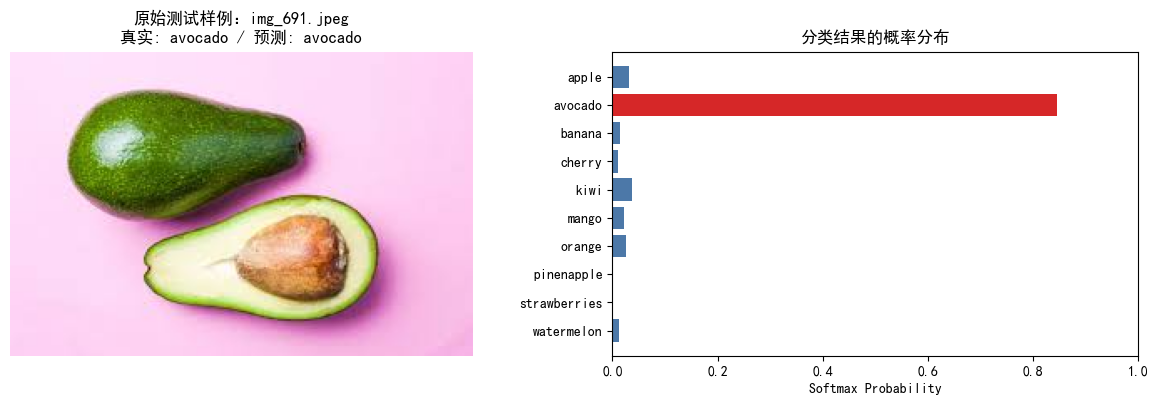

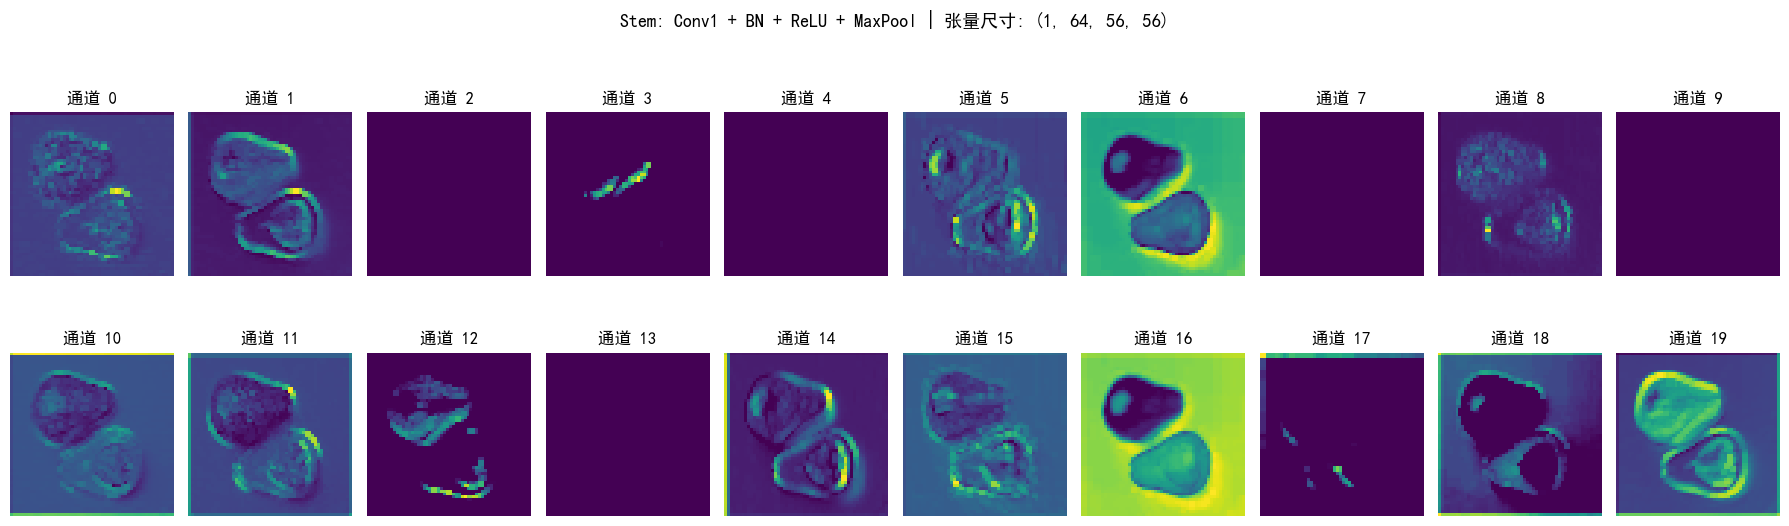

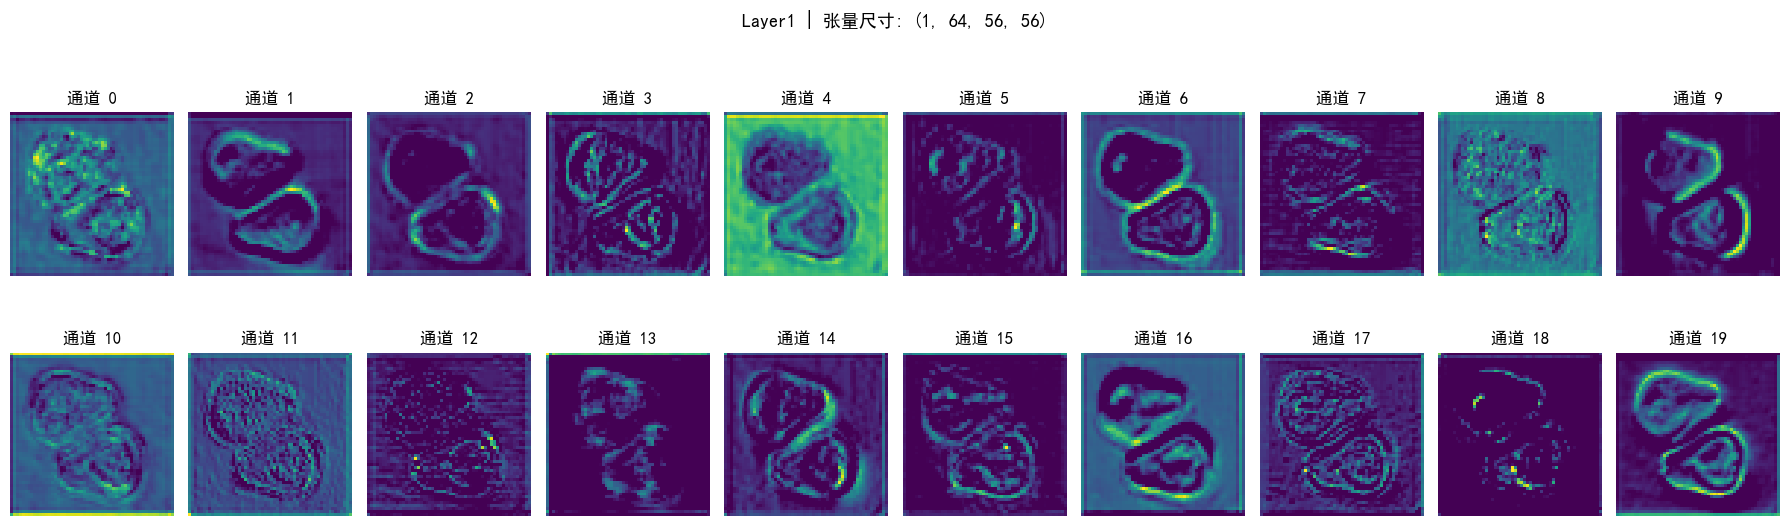

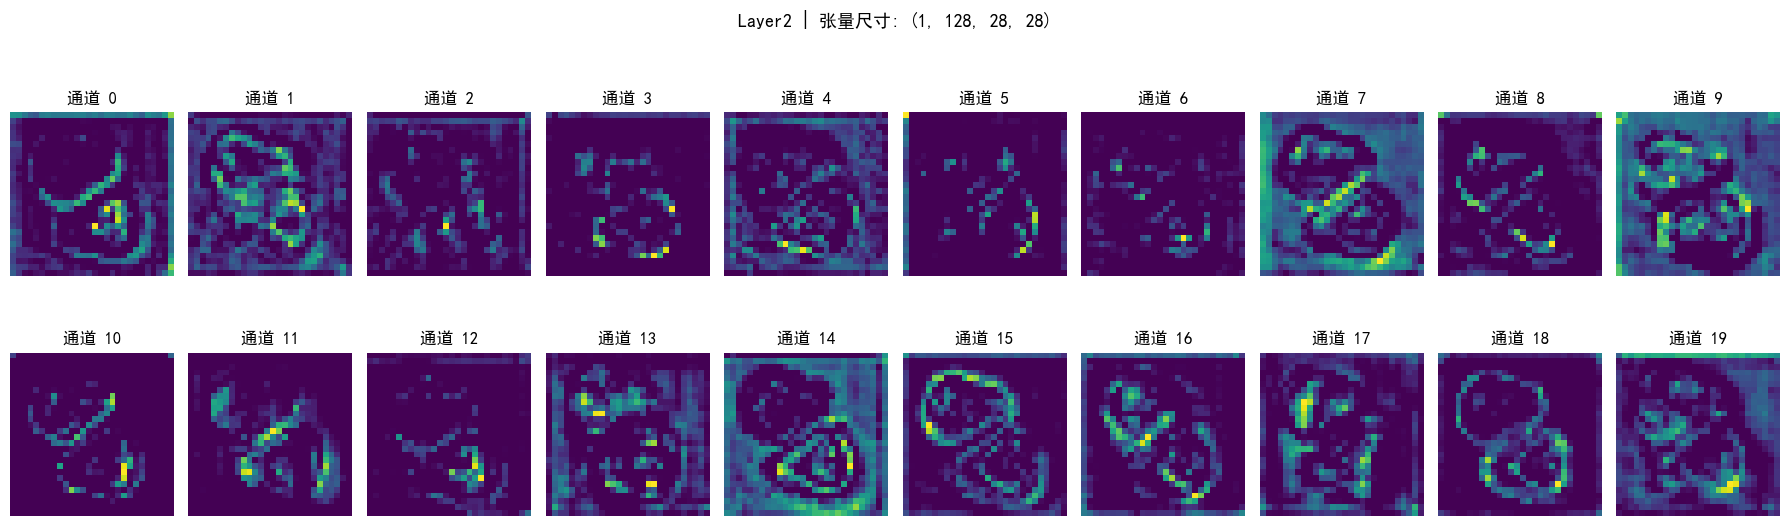

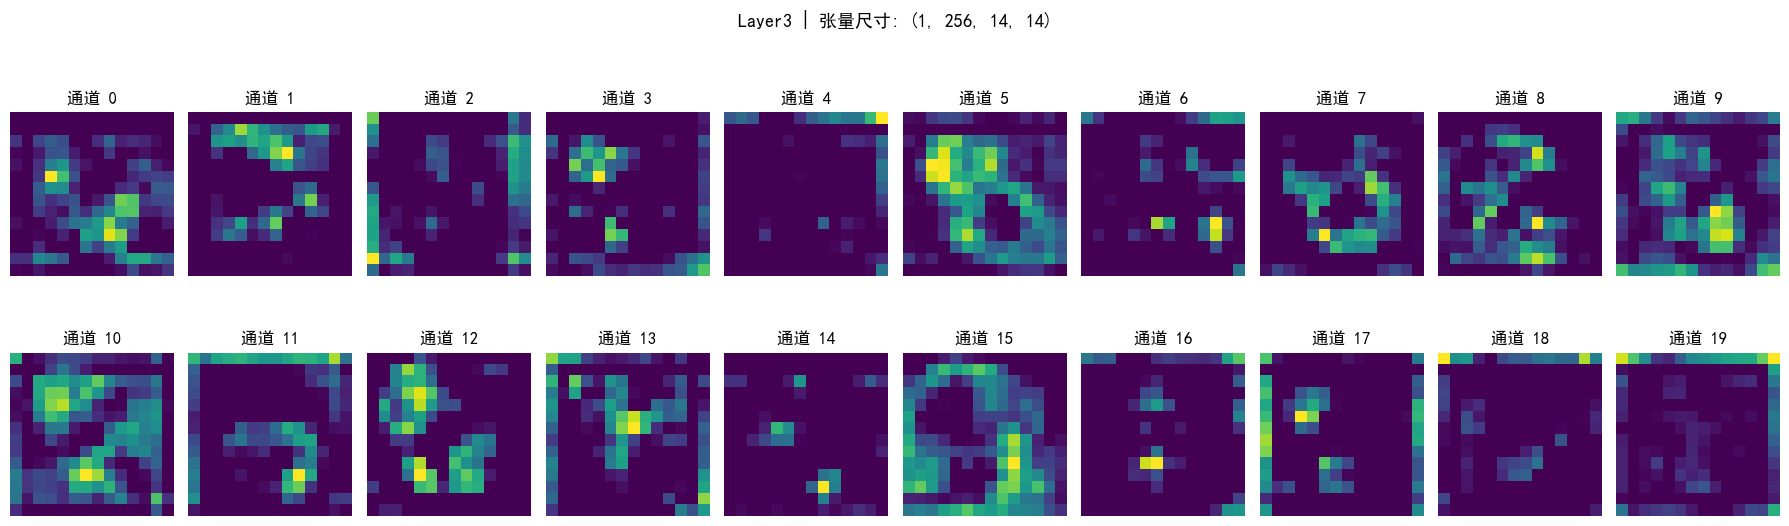

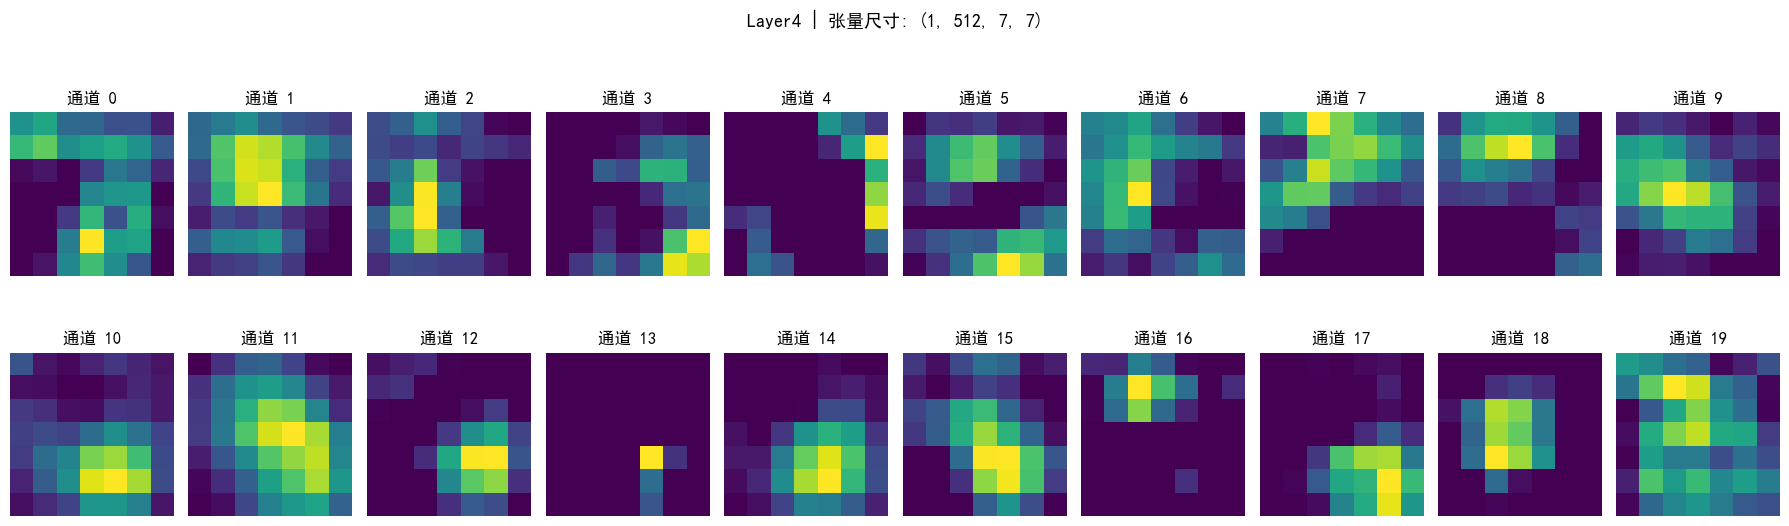

In [9]:
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 随机挑选一张测试样例，观察 ResNet18 的特征图变化
checkpoint_path = 'best_resnet18_simple.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'已加载最佳模型参数: {checkpoint_path}')
else:
    print('未找到已保存的最佳模型，将使用当前内存中的模型进行特征图可视化。')

model.eval()

sample_index = int(np.random.randint(0, len(test_dataset)))
image_path, true_label, canonical_name = test_dataset.samples[sample_index]
file_name = os.path.basename(image_path)
raw_image = Image.open(image_path).convert('RGB')
image_tensor = test_transform(raw_image).unsqueeze(0).to(device)

with torch.no_grad():
    stem = model.relu(model.bn1(model.conv1(image_tensor)))
    stem = model.maxpool(stem)
    feature_1 = model.layer1(stem)
    feature_2 = model.layer2(feature_1)
    feature_3 = model.layer3(feature_2)
    feature_4 = model.layer4(feature_3)
    logits = model(image_tensor)
    probabilities = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    predicted_label = int(np.argmax(probabilities))
    predicted_name = class_names[predicted_label]
    true_name = class_names[true_label]

layer_outputs = [
    ('Stem: Conv1 + BN + ReLU + MaxPool', stem.cpu()),
    ('Layer1', feature_1.cpu()),
    ('Layer2', feature_2.cpu()),
    ('Layer3', feature_3.cpu()),
    ('Layer4', feature_4.cpu()),
]

print(f'随机样本索引: {sample_index}')
print(f'测试图片路径: {image_path}')
print(f'真实类别: {true_name}')
print(f'预测类别: {predicted_name}')
print('各层张量尺寸变化:')
print(f'输入: {tuple(image_tensor.shape)}')
print(f'Stem: {tuple(stem.shape)}')
print(f'Layer1: {tuple(feature_1.shape)}')
print(f'Layer2: {tuple(feature_2.shape)}')
print(f'Layer3: {tuple(feature_3.shape)}')
print(f'Layer4: {tuple(feature_4.shape)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(raw_image)
axes[0].set_title(f'原始测试样例：{file_name}\n真实: {true_name} / 预测: {predicted_name}')
axes[0].axis('off')

bar_colors = ['#d62728' if idx == predicted_label else '#4C78A8' for idx in range(len(class_names))]
axes[1].barh(class_names, probabilities, color=bar_colors)
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Softmax Probability')
axes[1].set_title('分类结果的概率分布')
plt.tight_layout()
plt.show()

for layer_name, feature_tensor in layer_outputs:
    channels = min(20, feature_tensor.shape[1])
    fig, axes = plt.subplots(2, 10, figsize=(18, 6))
    fig.suptitle(f'{layer_name} | 张量尺寸: {tuple(feature_tensor.shape)}', fontsize=13)

    for feature_idx, ax_feature in enumerate(axes.flat):
        if feature_idx < channels:
            panel = feature_tensor[0, feature_idx].numpy()
            panel_min = panel.min()
            panel_max = panel.max()
            if panel_max > panel_min:
                panel = (panel - panel_min) / (panel_max - panel_min)
            ax_feature.imshow(panel, cmap='viridis', interpolation='nearest')
            ax_feature.set_title(f'通道 {feature_idx}')
            ax_feature.axis('off')
        else:
            ax_feature.axis('off')

    plt.tight_layout()
    plt.show()

已加载最佳模型参数: best_resnet18_simple.pth
本次随机展示 2 张正确样本和 2 张错误样本。
预测正确样本: ./archive/MY_data/test\banana\img_341.jpeg
预测类别: banana | 真实类别: banana
预测正确样本: ./archive/MY_data/test\apple\img_871.jpeg
预测类别: apple | 真实类别: apple
预测错误样本: ./archive/MY_data/test\stawberries\img_1001.jpeg
预测类别: cherry | 真实类别: strawberries
预测错误样本: ./archive/MY_data/test\stawberries\img_1561.jpeg
预测类别: watermelon | 真实类别: strawberries


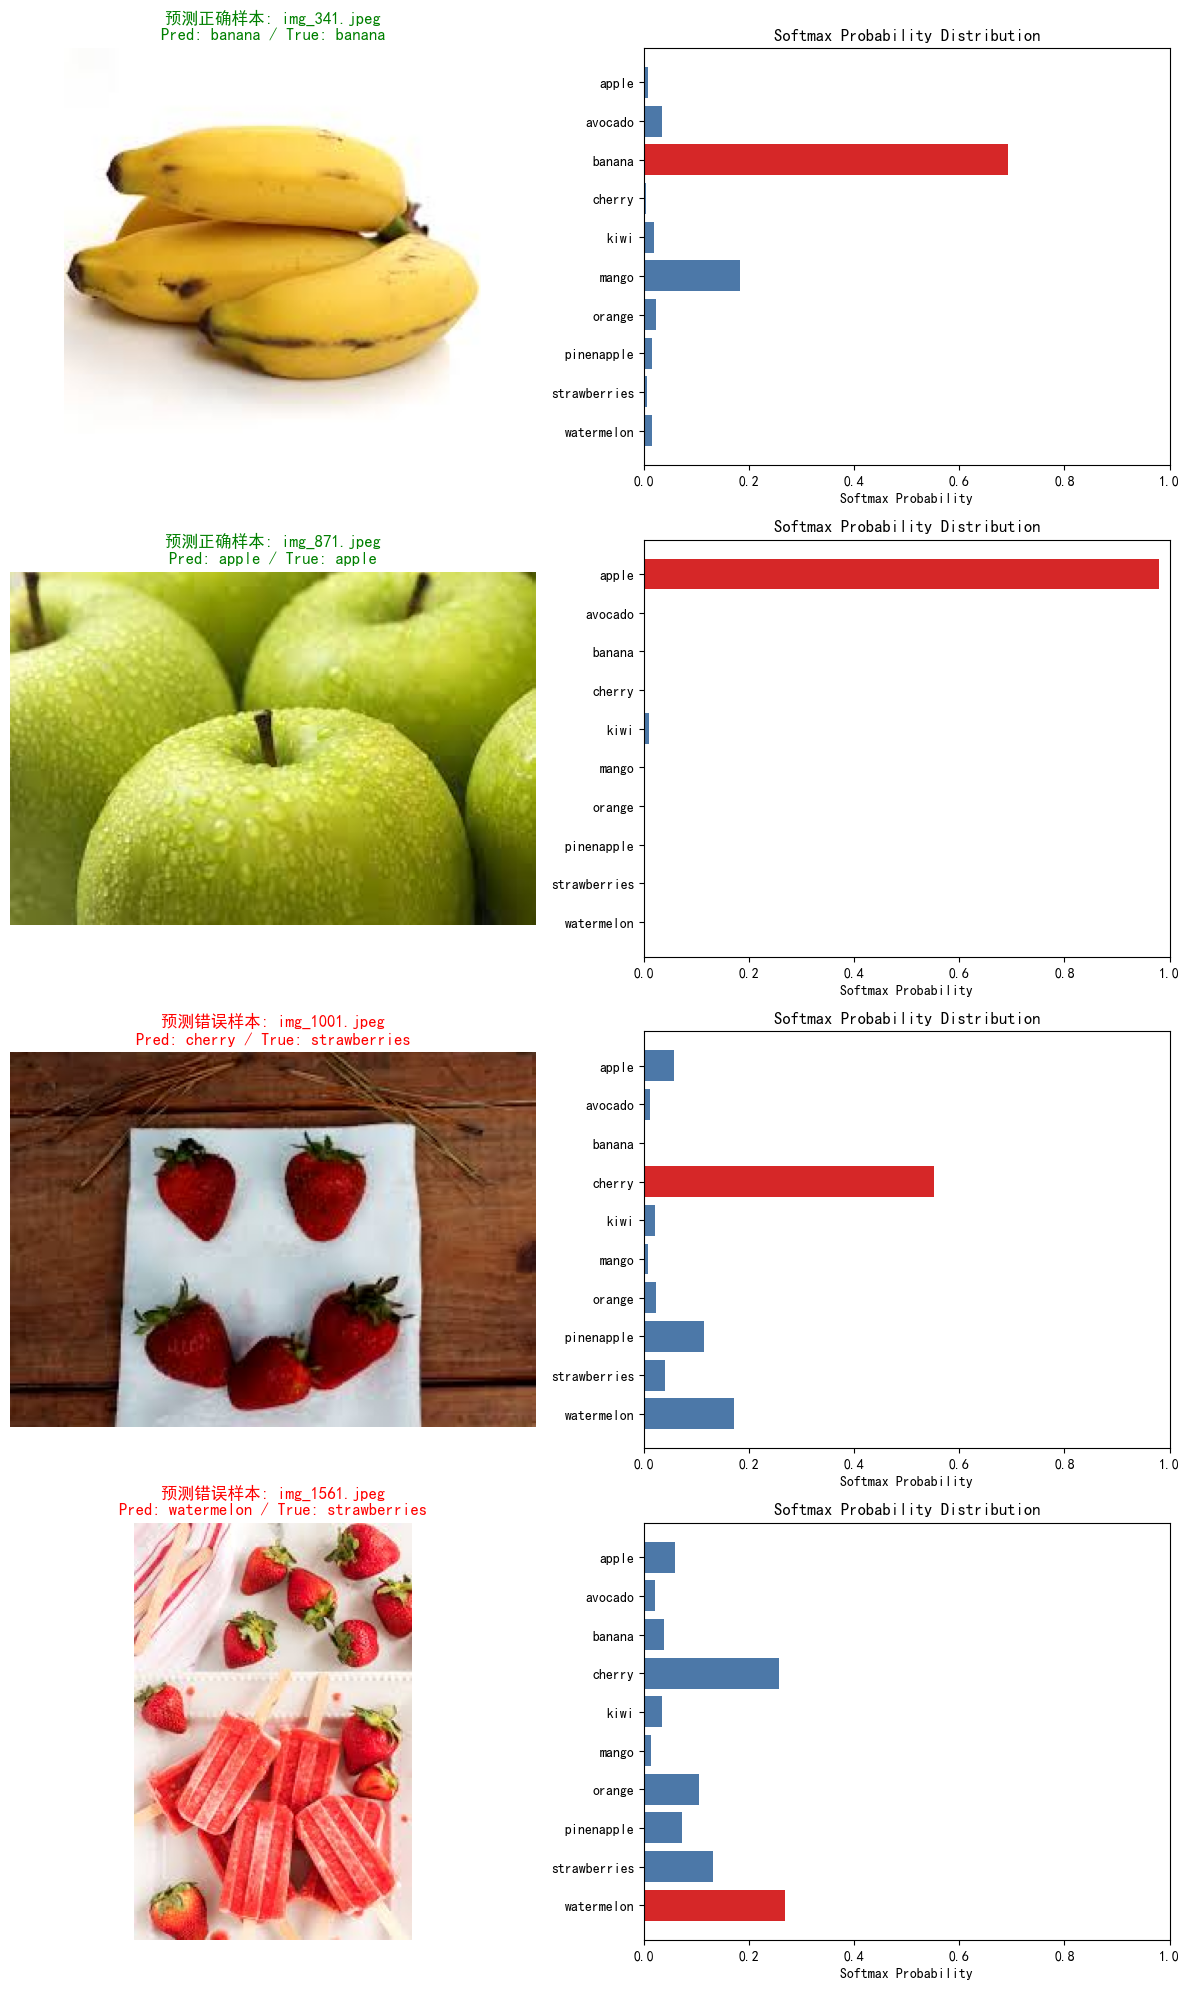

In [10]:
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 随机抽取 2 张预测正确样本和 2 张预测错误样本
checkpoint_path = 'best_resnet18_simple.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'已加载最佳模型参数: {checkpoint_path}')
else:
    print('未找到已保存的最佳模型，将使用当前内存中的模型进行预测。')

model.eval()
# rng = np.random.default_rng(42)
correct_cases = []
wrong_cases = []

with torch.no_grad():
    for image_path, true_label, canonical_name in test_dataset.samples:
        raw_image = Image.open(image_path).convert('RGB')
        image_tensor = test_transform(raw_image).unsqueeze(0).to(device)
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1).squeeze(0).cpu().numpy()
        predicted_label = int(np.argmax(probabilities))

        case = {
            'image_path': image_path,
            'raw_image': raw_image.copy(),
            'true_label': true_label,
            'predicted_label': predicted_label,
            'true_name': class_names[true_label],
            'predicted_name': class_names[predicted_label],
            'probabilities': probabilities,
        }

        if predicted_label == true_label:
            correct_cases.append(case)
        else:
            wrong_cases.append(case)

selected_cases = []

def pick_cases(cases, count):
    if not cases:
        return []
    pick_count = min(count, len(cases))
    chosen_indices = np.random.choice(len(cases), size=pick_count, replace=False)
    chosen_indices = np.atleast_1d(chosen_indices).tolist()
    return [cases[int(idx)] for idx in chosen_indices]

selected_cases.extend([('预测正确样本', case) for case in pick_cases(correct_cases, 2)])
selected_cases.extend([('预测错误样本', case) for case in pick_cases(wrong_cases, 2)])

if not selected_cases:
    print('测试集中暂时没有可展示的样本。')
else:
    fig, axes = plt.subplots(len(selected_cases), 2, figsize=(12, 5 * len(selected_cases)))
    if len(selected_cases) == 1:
        axes = np.array([axes])

    print(f'本次随机展示 {len([case for group, case in selected_cases if group == "预测正确样本"])} 张正确样本和 {len([case for group, case in selected_cases if group == "预测错误样本"])} 张错误样本。')

    for row_idx, (group_title, case) in enumerate(selected_cases):
        file_name = os.path.basename(case['image_path'])
        print(f"{group_title}: {case['image_path']}")
        print(f"预测类别: {case['predicted_name']} | 真实类别: {case['true_name']}")

        axes[row_idx, 0].imshow(case['raw_image'])
        title_color = 'green' if case['predicted_label'] == case['true_label'] else 'red'
        axes[row_idx, 0].set_title(
            f"{group_title}: {file_name}\nPred: {case['predicted_name']} / True: {case['true_name']}",
            color=title_color
        )
        axes[row_idx, 0].axis('off')

        bar_colors = ['#d62728' if idx == case['predicted_label'] else '#4C78A8' for idx in range(len(class_names))]
        axes[row_idx, 1].barh(class_names, case['probabilities'], color=bar_colors)
        axes[row_idx, 1].invert_yaxis()
        axes[row_idx, 1].set_xlim(0, 1)
        axes[row_idx, 1].set_xlabel('Softmax Probability')
        axes[row_idx, 1].set_title('Softmax Probability Distribution')

    plt.tight_layout()
    plt.show()

### 归一化混淆矩阵：分析哪些类别容易混淆

除了看总准确率，还可以通过归一化混淆矩阵分析模型最容易把哪些水果分错。

教学提示：

1. 每一行表示同一个真实类别，归一化后每行之和约为 1。
2. 对角线上的值越大，说明该类别识别越稳定。
3. 非对角线上的较大值表示“真实类别 A 经常被预测成类别 B”。

已加载最佳模型参数: best_resnet18_simple.pth


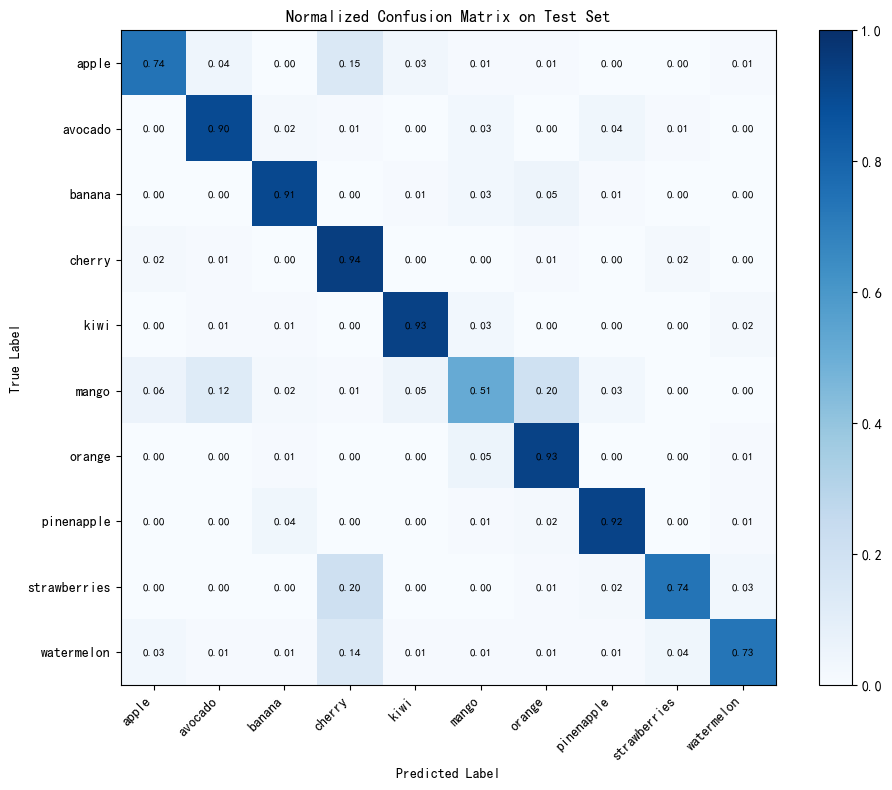

最容易混淆的前 3 对类别:
1. 真实类别 strawberries 最容易被预测成 cherry，归一化比例为 20.39%
2. 真实类别 mango 最容易被预测成 orange，归一化比例为 20.00%
3. 真实类别 apple 最容易被预测成 cherry，归一化比例为 14.61%


In [11]:
# 归一化混淆矩阵：统计测试集上每个类别的预测情况，并总结最易混淆的类别对
checkpoint_path = 'best_resnet18_simple.pth'
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f'已加载最佳模型参数: {checkpoint_path}')
else:
    print('未找到已保存的最佳模型，将使用当前内存中的模型计算混淆矩阵。')

model.eval()
confusion = np.zeros((num_classes, num_classes), dtype=int)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for true_label, pred_label in zip(labels.cpu().numpy(), preds.cpu().numpy()):
            confusion[true_label, pred_label] += 1

row_sums = confusion.sum(axis=1, keepdims=True)
confusion_normalized = np.divide(confusion, row_sums, out=np.zeros_like(confusion, dtype=float), where=row_sums != 0)

plt.figure(figsize=(10, 8))
plt.imshow(confusion_normalized, cmap='Blues', vmin=0, vmax=1)
plt.title('Normalized Confusion Matrix on Test Set')
plt.colorbar()
plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
plt.yticks(range(num_classes), class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

for row in range(num_classes):
    for col in range(num_classes):
        value = confusion_normalized[row, col]
        plt.text(col, row, f'{value:.2f}', ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.show()

confusion_pairs = []
for true_idx in range(num_classes):
    for pred_idx in range(num_classes):
        if true_idx != pred_idx and confusion_normalized[true_idx, pred_idx] > 0:
            confusion_pairs.append((confusion_normalized[true_idx, pred_idx], class_names[true_idx], class_names[pred_idx]))

confusion_pairs.sort(reverse=True, key=lambda item: item[0])
print('最容易混淆的前 3 对类别:')
for rank, (score, true_name, pred_name) in enumerate(confusion_pairs[:3], start=1):
    print(f'{rank}. 真实类别 {true_name} 最容易被预测成 {pred_name}，归一化比例为 {score:.2%}')

### 🤔课堂讨论：为什么原始写法可能会让准确率看起来偏低？

同学们可以从以下几个角度分析：

1. 训练集与测试集的文件夹命名不一致，会导致类别编号映射错位。
2. 数据集规模较小时，单纯冻结主干网络并只训练最后一层，效果可能受限。
3. 增强方式如果不合理，也可能破坏水果图像的关键形状特征。

建议进一步尝试：

1. 输出每个类别的样本数量，观察数据是否均衡。
2. 生成混淆矩阵，分析最容易混淆的是哪几类水果。
3. 尝试解冻 ResNet18 的最后一个残差模块，再比较结果变化。

### 📓课后作业：给水果分类模型做一次“诊断 + 改进”

注意：本教程已经给出了训练代码、随机样例分析、归一化混淆矩阵和易混淆类别统计。因此，课后作业不再要求大家重复“把这些图重新画出来”，而是要求你基于现有结果做进一步分析和优化。

【任务目标】

1. 阅读教程已经生成的基线结果，找出模型当前最容易分错的类别。
   重点不是“会不会画混淆矩阵”，而是“能不能从混淆矩阵里读出问题”。建议至少指出 2 组明显的易混淆类别，并说明你为什么怀疑它们容易混。

2. 借助 AI 充当一次“模型医生”，分析误判原因，并选择 1 到 2 个合理改进点。
   可以从这些方向中选择：
   - 数据层面：类别样本数量不均衡、部分类别图片背景太复杂、训练集和测试集分布差异较大。
   - 模型层面：只训练最后一层可能不够、训练轮数偏少、学习率不合适。
   - 增强层面：当前数据增强可能不够，或者某些增强方式对水果识别帮助有限。
   - 类别层面：某些水果外观本来就相似，例如颜色、形状、纹理接近。

3. 完成一次小幅优化，并用“前后对比”证明你的优化是有效的。
   不要求做到 100% 正确，只要优化后没有出现明显异常，并且能看出某些类别的混淆减轻、或者整体准确率有所提升，就算完成任务。

【提交要求】

不用提交代码，只提交 1 个 Word 文档。建议文档控制在 1 到 2 页，包含 3 张结果图，并配上简短说明。


1. 图 1：教程当前的基线混淆矩阵与错误样例展示。
   分析：你认为哪几类最容易混淆？为什么会产生这样的错误？你的优化方案是什么？

2. 图 2：你完成优化后的关键结果。
   可以截取优化后的测试准确率、最佳准确率，或者训练/测试结果对比图。重点是让老师看出“你做了优化，而且结果发生了变化”。

3. 图 3：优化后的新混淆矩阵与样例对比展示。
   请在旁边写一句话：和原来的混淆矩阵相比，哪些地方变好了？哪些原来分类错误的样本现在被正确分类了？激活概率分布发生了什么变化？

【分析文字说明建议】

请在截图之间补充 3 到 5 句简短说明，尽量写清楚这三件事：

1. 你观察到了什么问题。
2. 你做了什么优化。
3. 优化后有什么变化。

【可直接采用的优化方向示例】

- 在 AI 帮助下尝试解冻 ResNet18 的最后一个残差模块，而不只是训练最后的全连接层。
- 适当增加训练轮数，观察测试准确率是否继续提升。
- 微调学习率，比较不同设置下的结果变化。
- 调整数据增强策略，使它更适合水果图像。
- 检查最容易混淆的类别样本，看看是否存在背景、角度、遮挡或标注问题。

【评价重点】

本次作业重点看“分析是否合理、优化是否有依据、前后对比是否清楚”，不以追求满分准确率为目标。